# PRISM Drug Repurposing Screen Analysis

This notebook analyzes raw plate-level PRISM Repurposing screen data from Corsello et al. 2020.

The goal is to start from raw per-well MFI measurements and build a reproducible analysis workflow for:

1. primary screen quality control,
2. primary screen normalization and hit calling,
3. hit triage for dose-response follow-up,
4. secondary screen quality control and normalization,
5. dose-response curve fitting,
6. selective killing analysis,
7. biomarker association and prediction,
8. mechanism exploration,
9. repurposing candidate prioritization.

This notebook preserves raw data unchanged. All processed outputs will be written to separate folders.

In [30]:
import sys

print(sys.executable)

c:\Users\shash\Desktop\Code for assignment\notebooks\.venv\Scripts\python.exe


In [31]:
import sys

print(sys.executable)

c:\Users\shash\Desktop\Code for assignment\notebooks\.venv\Scripts\python.exe


In [32]:
import sys

!{sys.executable} -m pip install numpy pandas matplotlib seaborn scipy scikit-learn statsmodels pyarrow openpyxl


'c:\Users\shash\Desktop\Code' is not recognized as an internal or external command,
operable program or batch file.


In [33]:
import sys

!{sys.executable} -m pip install numpy pandas matplotlib seaborn scipy scikit-learn statsmodels pyarrow openpyxl

'c:\Users\shash\Desktop\Code' is not recognized as an internal or external command,
operable program or batch file.


In [34]:
import sys

python_path = f'"{sys.executable}"'
print(python_path)

"c:\Users\shash\Desktop\Code for assignment\notebooks\.venv\Scripts\python.exe"


In [35]:
import sys

!"{sys.executable}" -m pip install numpy pandas matplotlib seaborn scipy scikit-learn statsmodels pyarrow openpyxl

In [36]:
from pathlib import Path
import os
import textwrap

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
# Project root folder
PROJECT_DIR = Path(r"C:\Users\shash\Desktop\Code for assignment")

# Main folders
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

RESULTS_DIR = PROJECT_DIR / "results"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

REPORTS_DIR = PROJECT_DIR / "reports"

# Create folders if they do not already exist
for folder in [
    DATA_DIR,
    RAW_DIR,
    PROCESSED_DIR,
    RESULTS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    REPORTS_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Raw data directory:", RAW_DIR)

Project directory: C:\Users\shash\Desktop\Code for assignment
Raw data directory: C:\Users\shash\Desktop\Code for assignment\data\raw


In [38]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 50)
pd.set_option("display.width", 120)

sns.set_context("notebook")

print("Display settings loaded.")

Display settings loaded.


In [39]:
def inventory_files(folder):
    """
    Return a table of files in a folder without reading full file contents.
    """
    folder = Path(folder)

    rows = []
    for path in sorted(folder.rglob("*")):
        if path.is_file():
            rows.append({
                "relative_path": path.relative_to(folder),
                "file_name": path.name,
                "suffix": path.suffix.lower(),
                "size_mb": path.stat().st_size / (1024 ** 2),
            })

    return pd.DataFrame(rows)


raw_inventory = inventory_files(RAW_DIR)

print(f"Found {len(raw_inventory)} files in raw data folder.")
raw_inventory

Found 23 files in raw data folder.


,relative_path,file_name,suffix,size_mb
0,CCLE_expression.csv,CCLE_expression.csv,.csv,286.563055
1,CCLE_gene_cn.csv,CCLE_gene_cn.csv,.csv,637.766252
2,CCLE_mutations.csv,CCLE_mutations.csv,.csv,276.733011
3,features\Confounders.csv,Confounders.csv,.csv,0.060482
4,features\Copy Number Alterations.csv,Copy Number Alterations.csv,.csv,165.357536
5,features\CRISPR.csv,CRISPR.csv,.csv,117.430954
6,features\D2.csv,D2.csv,.csv,152.287231
7,features\Hotspot Mutations.csv,Hotspot Mutations.csv,.csv,118.464334
8,features\Metabolomics.csv,Metabolomics.csv,.csv,3.036568
9,features\Methylation.csv,Methylation.csv,.csv,246.978885


In [40]:
def preview_csv(path, nrows=5):
    """
    Safely preview a CSV file without loading the full dataset.
    Useful for checking column names and structure before analysis.
    """
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    preview = pd.read_csv(path, nrows=nrows)

    print(f"File: {path.name}")
    print(f"Preview rows: {preview.shape[0]}")
    print(f"Preview columns: {preview.shape[1]}")
    print("\nColumn names:")
    for col in preview.columns[:30]:
        print(f"  - {col}")

    if preview.shape[1] > 30:
        print(f"  ... {preview.shape[1] - 30} more columns")

    return preview


In [41]:
def preview_text_file(path, max_lines=40):
    """
    Preview the beginning of a text or README file.
    """
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    with open(path, "r", encoding="utf-8", errors="replace") as file:
        lines = file.readlines()

    print(f"File: {path.name}")
    print(f"Total lines shown: {min(len(lines), max_lines)}")
    print("-" * 80)

    for line in lines[:max_lines]:
        print(line.rstrip())

In [42]:
raw_inventory

,relative_path,file_name,suffix,size_mb
0,CCLE_expression.csv,CCLE_expression.csv,.csv,286.563055
1,CCLE_gene_cn.csv,CCLE_gene_cn.csv,.csv,637.766252
2,CCLE_mutations.csv,CCLE_mutations.csv,.csv,276.733011
3,features\Confounders.csv,Confounders.csv,.csv,0.060482
4,features\Copy Number Alterations.csv,Copy Number Alterations.csv,.csv,165.357536
5,features\CRISPR.csv,CRISPR.csv,.csv,117.430954
6,features\D2.csv,D2.csv,.csv,152.287231
7,features\Hotspot Mutations.csv,Hotspot Mutations.csv,.csv,118.464334
8,features\Metabolomics.csv,Metabolomics.csv,.csv,3.036568
9,features\Methylation.csv,Methylation.csv,.csv,246.978885


## 0.1 Inspect README and File Schemas

Before loading the large raw MFI matrices, we first inspect the README and small metadata files. This prevents us from guessing column names or making assumptions about how wells, compounds, doses, plates, pools, and cell lines are encoded.

In [43]:
preview_text_file(RAW_DIR / "README.md", max_lines=80)

File: README.md
Total lines shown: 80
--------------------------------------------------------------------------------
# PRISM Repurposing Screen Data Bundle

## Provenance

Raw screening data from Corsello et al. 2020 (Nature Cancer):
"Discovering the anti-cancer potential of non-oncology drugs by systematic
viability profiling"

DOI: 10.1038/s43018-019-0018-6
Data source: https://depmap.org/repurposing

## Assay

PRISM (Profiling Relative Inhibition Simultaneously in Mixtures) is a
multiplexed cell viability assay. Cancer cell lines are labeled with unique
DNA barcodes, pooled in groups of ~25 (matched by doubling time), and treated
with compounds. After 5 days of incubation, cells are lysed and barcode
abundance is measured via Luminex bead-based detection. The median
fluorescence intensity (MFI) of each barcode serves as a surrogate for the
relative viability of that cell line.

## Screens

**Primary screen:** 4,518 compounds tested at a single dose (2.5 uM) across
578 cell lines i

In [44]:
primary_treatment_preview = preview_csv(
    RAW_DIR / "primary-screen-replicate-treatment-info.csv",
    nrows=5
)

primary_cell_line_preview = preview_csv(
    RAW_DIR / "primary-screen-cell-line-info.csv",
    nrows=5
)

primary_pooling_preview = preview_csv(
    RAW_DIR / "primary-screen-pooling-info.csv",
    nrows=5
)

File: primary-screen-replicate-treatment-info.csv
Preview rows: 5
Preview columns: 18

Column names:
  - column_name
  - broad_id
  - name
  - dose
  - perturbation_type
  - screen_id
  - detection_plate
  - compound_plate
  - well
  - detection_plate_scan_time
  - vendor_id
  - purity
  - moa
  - target
  - disease.area
  - indication
  - smiles
  - phase
File: primary-screen-cell-line-info.csv
Preview rows: 5
Preview columns: 10

Column names:
  - row_name
  - depmap_id
  - ccle_name
  - primary_tissue
  - secondary_tissue
  - tertiary_tissue
  - passed_str_profiling
  - str_profiling_notes
  - originally_assigned_depmap_id
  - originally_assigned_ccle_name
File: primary-screen-pooling-info.csv
Preview rows: 5
Preview columns: 7

Column names:
  - row_name
  - screen_id
  - analyte_id
  - detection_pool
  - minipool_id
  - pool_id
  - passed_str_profiling


In [45]:
secondary_treatment_preview = preview_csv(
    RAW_DIR / "secondary-screen-replicate-treatment-info.csv",
    nrows=5
)

secondary_cell_line_preview = preview_csv(
    RAW_DIR / "secondary-screen-cell-line-info.csv",
    nrows=5
)

secondary_pooling_preview = preview_csv(
    RAW_DIR / "secondary-screen-pooling-info.csv",
    nrows=5
)

File: secondary-screen-replicate-treatment-info.csv
Preview rows: 5
Preview columns: 12

Column names:
  - column_name
  - broad_id
  - dose
  - screen_id
  - compound_plate
  - name
  - moa
  - target
  - disease.area
  - indication
  - smiles
  - phase
File: secondary-screen-cell-line-info.csv
Preview rows: 5
Preview columns: 7

Column names:
  - row_name
  - depmap_id
  - ccle_name
  - primary_tissue
  - secondary_tissue
  - tertiary_tissue
  - passed_str_profiling
File: secondary-screen-pooling-info.csv
Preview rows: 5
Preview columns: 9

Column names:
  - row_name
  - depmap_id
  - passed_str_profiling
  - ccle_name
  - screen_id
  - analyte_id
  - detection_pool
  - minipool_id
  - pool_id


In [46]:
primary_mfi_preview = preview_csv(
    RAW_DIR / "primary-screen-primary-mfi.csv",
    nrows=5
)

secondary_mfi_preview = preview_csv(
    RAW_DIR / "secondary-screen-mfi.csv",
    nrows=5
)

File: primary-screen-primary-mfi.csv
Preview rows: 5
Preview columns: 17059

Column names:
  - Unnamed: 0
  - PREP001_X1:A01::HTS
  - PREP001_X1:A02::HTS
  - PREP001_X1:A03::HTS
  - PREP001_X1:A04::HTS
  - PREP001_X1:A05::HTS
  - PREP001_X1:A06::HTS
  - PREP001_X1:A07::HTS
  - PREP001_X1:A08::HTS
  - PREP001_X1:A09::HTS
  - PREP001_X1:A10::HTS
  - PREP001_X1:A11::HTS
  - PREP001_X1:A12::HTS
  - PREP001_X1:A13::HTS
  - PREP001_X1:A14::HTS
  - PREP001_X1:A15::HTS
  - PREP001_X1:A16::HTS
  - PREP001_X1:A17::HTS
  - PREP001_X1:A18::HTS
  - PREP001_X1:A19::HTS
  - PREP001_X1:A20::HTS
  - PREP001_X1:A21::HTS
  - PREP001_X1:A22::HTS
  - PREP001_X1:A23::HTS
  - PREP001_X1:A24::HTS
  - PREP001_X1:B01::HTS
  - PREP001_X1:B02::HTS
  - PREP001_X1:B03::HTS
  - PREP001_X1:B04::HTS
  - PREP001_X1:B05::HTS
  ... 17029 more columns
File: secondary-screen-mfi.csv
Preview rows: 5
Preview columns: 48968

Column names:
  - Unnamed: 0
  - PMTS004_PR500.2_X1:A01::MTS005
  - PMTS004_PR500.2_X1:A02::MTS005
  -

In [47]:
primary_mfi_preview = preview_csv(
    RAW_DIR / "primary-screen-primary-mfi.csv",
    nrows=5
)

secondary_mfi_preview = preview_csv(
    RAW_DIR / "secondary-screen-mfi.csv",
    nrows=5
)

File: primary-screen-primary-mfi.csv
Preview rows: 5
Preview columns: 17059

Column names:
  - Unnamed: 0
  - PREP001_X1:A01::HTS
  - PREP001_X1:A02::HTS
  - PREP001_X1:A03::HTS
  - PREP001_X1:A04::HTS
  - PREP001_X1:A05::HTS
  - PREP001_X1:A06::HTS
  - PREP001_X1:A07::HTS
  - PREP001_X1:A08::HTS
  - PREP001_X1:A09::HTS
  - PREP001_X1:A10::HTS
  - PREP001_X1:A11::HTS
  - PREP001_X1:A12::HTS
  - PREP001_X1:A13::HTS
  - PREP001_X1:A14::HTS
  - PREP001_X1:A15::HTS
  - PREP001_X1:A16::HTS
  - PREP001_X1:A17::HTS
  - PREP001_X1:A18::HTS
  - PREP001_X1:A19::HTS
  - PREP001_X1:A20::HTS
  - PREP001_X1:A21::HTS
  - PREP001_X1:A22::HTS
  - PREP001_X1:A23::HTS
  - PREP001_X1:A24::HTS
  - PREP001_X1:B01::HTS
  - PREP001_X1:B02::HTS
  - PREP001_X1:B03::HTS
  - PREP001_X1:B04::HTS
  - PREP001_X1:B05::HTS
  ... 17029 more columns
File: secondary-screen-mfi.csv
Preview rows: 5
Preview columns: 48968

Column names:
  - Unnamed: 0
  - PMTS004_PR500.2_X1:A01::MTS005
  - PMTS004_PR500.2_X1:A02::MTS005
  -

In [48]:
# Confirm that the key files exist and preview their dimensions safely
key_files = [
    "primary-screen-primary-mfi.csv",
    "secondary-screen-mfi.csv",
    "primary-screen-replicate-treatment-info.csv",
    "secondary-screen-replicate-treatment-info.csv",
]

for file_name in key_files:
    path = RAW_DIR / file_name
    print(file_name)
    print("  Exists:", path.exists())
    print("  Size MB:", round(path.stat().st_size / (1024 ** 2), 2))
    print()

primary-screen-primary-mfi.csv
  Exists: True
  Size MB: 64.36

secondary-screen-mfi.csv
  Exists: True
  Size MB: 161.14

primary-screen-replicate-treatment-info.csv
  Exists: True
  Size MB: 4.93

secondary-screen-replicate-treatment-info.csv
  Exists: True
  Size MB: 3.61



In [49]:
# Read only headers and 2 rows from the two raw MFI matrices
primary_mfi_preview = pd.read_csv(
    RAW_DIR / "primary-screen-primary-mfi.csv",
    nrows=2
)

secondary_mfi_preview = pd.read_csv(
    RAW_DIR / "secondary-screen-mfi.csv",
    nrows=2
)

print("Primary MFI preview shape:", primary_mfi_preview.shape)
print("Primary first 5 columns:")
print(primary_mfi_preview.columns[:5].tolist())

print()

print("Secondary MFI preview shape:", secondary_mfi_preview.shape)
print("Secondary first 5 columns:")
print(secondary_mfi_preview.columns[:5].tolist())

Primary MFI preview shape: (2, 17059)
Primary first 5 columns:
['Unnamed: 0', 'PREP001_X1:A01::HTS', 'PREP001_X1:A02::HTS', 'PREP001_X1:A03::HTS', 'PREP001_X1:A04::HTS']

Secondary MFI preview shape: (2, 48968)
Secondary first 5 columns:
['Unnamed: 0', 'PMTS004_PR500.2_X1:A01::MTS005', 'PMTS004_PR500.2_X1:A02::MTS005', 'PMTS004_PR500.2_X1:A23::MTS005', 'PMTS004_PR500.2_X1:A24::MTS005']


In [50]:
primary_treatment = pd.read_csv(
    RAW_DIR / "primary-screen-replicate-treatment-info.csv"
)

secondary_treatment = pd.read_csv(
    RAW_DIR / "secondary-screen-replicate-treatment-info.csv"
)

print("Primary treatment shape:", primary_treatment.shape)
print("Secondary treatment shape:", secondary_treatment.shape)

display(primary_treatment.head())
display(secondary_treatment.head())

Primary treatment shape: (17058, 18)
Secondary treatment shape: (13008, 12)


,column_name,broad_id,name,dose,perturbation_type,screen_id,detection_plate,compound_plate,well,detection_plate_scan_time,vendor_id,purity,moa,target,disease.area,indication,smiles,phase
0,PREP001_X1:A01::HTS,BRD-K60230970-001-14-2,MG-132,20.0,positive_control,HTS,PREP001_X1,PREP001,A01,2/11/2016 10:09 AM,S2619,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PREP001_X1:A02::HTS,NaN,NaN,NaN,vehicle_control,HTS,PREP001_X1,PREP001,A02,2/11/2016 10:09 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PREP001_X1:A03::HTS,BRD-A96485169-001-14-3,EBPC,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A03,2/11/2016 10:09 AM,518,91.11,aldose reductase inhibitor,AKR1B1,NaN,NaN,CCOC(=O)C1CN(Cc2ccccc2)C(=O)C1=O,Preclinical
3,PREP001_X1:A04::HTS,BRD-K35559145-050-08-5,levomepromazine,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A04,2/11/2016 10:09 AM,Prestw-797,76.90,dopamine receptor antagonist,"ADRA1A, ADRA1B, ADRA1D, ADRA2A, ADRA2B, ADRA2C...","neurology/psychiatry, gastroenterology","psychosis, schizophrenia, bipolar disorder, na...","COc1ccc2Sc3ccccc3N(C[C@H](C)CN(C)C)c2c1, COc1c...",Launched
4,PREP001_X1:A05::HTS,BRD-A48015106-004-08-9,8-hydroxy-DPAT,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A05,2/11/2016 10:09 AM,529,93.13,serotonin receptor agonist,"CDK1, CHEK1, CHEK2, GSK3B, HTR5A, HTR7, LCK, M...",NaN,NaN,CCCN(CCC)C1CCc2cccc(O)c2C1,Preclinical


,column_name,broad_id,dose,screen_id,compound_plate,name,moa,target,disease.area,indication,smiles,phase
0,BRD-A25234499-001-19-1::0.00061::MTS010::PROS0...,BRD-A25234499-001-19-1,0.00061,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched
1,BRD-A25234499-001-19-1::0.00244::MTS010::PROS0...,BRD-A25234499-001-19-1,0.00244,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched
2,BRD-A25234499-001-19-1::0.00977::MTS010::PROS0...,BRD-A25234499-001-19-1,0.00977,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched
3,BRD-A25234499-001-19-1::0.0391::MTS010::PROS00...,BRD-A25234499-001-19-1,0.03910,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched
4,BRD-A25234499-001-19-1::0.15625::MTS010::PROS0...,BRD-A25234499-001-19-1,0.15625,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched


## 1. Primary Screen QC: Initial Data Loading and Schema Validation

We begin with the primary screen because it is the single-dose screen used for initial hit discovery.

Before performing quality control or normalization, we validate the relationship between:

- the raw MFI matrix,
- treatment metadata,
- cell line metadata,
- pooling metadata.

The main goal here is to confirm that the well columns in the raw MFI matrix map cleanly to the treatment metadata.

In [104]:
primary_treatment = pd.read_csv(
    RAW_DIR / "primary-screen-replicate-treatment-info.csv"
)

primary_cell_lines = pd.read_csv(
    RAW_DIR / "primary-screen-cell-line-info.csv"
)

primary_pooling = pd.read_csv(
    RAW_DIR / "primary-screen-pooling-info.csv"
)

print("Primary treatment shape:", primary_treatment.shape)
print("Primary cell line info shape:", primary_cell_lines.shape)
print("Primary pooling info shape:", primary_pooling.shape)

Primary treatment shape: (17058, 18)
Primary cell line info shape: (588, 10)
Primary pooling info shape: (2637, 7)


In [105]:
primary_mfi = pd.read_csv(
    RAW_DIR / "primary-screen-primary-mfi.csv"
)

print("Primary MFI shape:", primary_mfi.shape)
primary_mfi.head()

Primary MFI shape: (588, 17059)


,Unnamed: 0,PREP001_X1:A01::HTS,PREP001_X1:A02::HTS,PREP001_X1:A03::HTS,PREP001_X1:A04::HTS,PREP001_X1:A05::HTS,PREP001_X1:A06::HTS,PREP001_X1:A07::HTS,PREP001_X1:A08::HTS,PREP001_X1:A09::HTS,PREP001_X1:A10::HTS,PREP001_X1:A11::HTS,PREP001_X1:A12::HTS,PREP001_X1:A13::HTS,PREP001_X1:A14::HTS,PREP001_X1:A15::HTS,PREP001_X1:A16::HTS,PREP001_X1:A17::HTS,PREP001_X1:A18::HTS,PREP001_X1:A19::HTS,PREP001_X1:A20::HTS,PREP001_X1:A21::HTS,PREP001_X1:A22::HTS,PREP001_X1:A23::HTS,PREP001_X1:A24::HTS,PREP001_X1:B01::HTS,PREP001_X1:B02::HTS,PREP001_X1:B03::HTS,PREP001_X1:B04::HTS,PREP001_X1:B05::HTS,PREP001_X1:B06::HTS,PREP001_X1:B07::HTS,PREP001_X1:B08::HTS,PREP001_X1:B09::HTS,PREP001_X1:B10::HTS,PREP001_X1:B11::HTS,PREP001_X1:B12::HTS,PREP001_X1:B13::HTS,PREP001_X1:B14::HTS,PREP001_X1:B15::HTS,PREP001_X1:B16::HTS,PREP001_X1:B17::HTS,PREP001_X1:B18::HTS,PREP001_X1:B19::HTS,PREP001_X1:B20::HTS,PREP001_X1:B21::HTS,PREP001_X1:B22::HTS,PREP001_X1:B23::HTS,PREP001_X1:B24::HTS,PREP001_X1:C01::HTS,...,PMTS003_X3:D23::MTS004,PMTS003_X3:D24::MTS004,PMTS003_X3:E01::MTS004,PMTS003_X3:E02::MTS004,PMTS003_X3:E23::MTS004,PMTS003_X3:E24::MTS004,PMTS003_X3:F01::MTS004,PMTS003_X3:F02::MTS004,PMTS003_X3:F23::MTS004,PMTS003_X3:F24::MTS004,PMTS003_X3:G01::MTS004,PMTS003_X3:G02::MTS004,PMTS003_X3:G23::MTS004,PMTS003_X3:G24::MTS004,PMTS003_X3:H01::MTS004,PMTS003_X3:H02::MTS004,PMTS003_X3:H23::MTS004,PMTS003_X3:H24::MTS004,PMTS003_X3:I01::MTS004,PMTS003_X3:I02::MTS004,PMTS003_X3:I23::MTS004,PMTS003_X3:I24::MTS004,PMTS003_X3:J01::MTS004,PMTS003_X3:J02::MTS004,PMTS003_X3:J23::MTS004,PMTS003_X3:J24::MTS004,PMTS003_X3:K01::MTS004,PMTS003_X3:K02::MTS004,PMTS003_X3:K23::MTS004,PMTS003_X3:K24::MTS004,PMTS003_X3:L01::MTS004,PMTS003_X3:L02::MTS004,PMTS003_X3:L23::MTS004,PMTS003_X3:L24::MTS004,PMTS003_X3:M01::MTS004,PMTS003_X3:M02::MTS004,PMTS003_X3:M23::MTS004,PMTS003_X3:M24::MTS004,PMTS003_X3:N01::MTS004,PMTS003_X3:N02::MTS004,PMTS003_X3:N23::MTS004,PMTS003_X3:N24::MTS004,PMTS003_X3:O01::MTS004,PMTS003_X3:O02::MTS004,PMTS003_X3:O23::MTS004,PMTS003_X3:O24::MTS004,PMTS003_X3:P01::MTS004,PMTS003_X3:P02::MTS004,PMTS003_X3:P23::MTS004,PMTS003_X3:P24::MTS004
0,ACH-000001,109.0,213.0,236.0,473.0,330.5,221.5,189.0,193.0,240.0,170.0,144.0,146.0,213.0,231.5,219.0,99.0,248.0,100.0,225.0,160.5,197.0,178.5,82.5,201.0,105.0,251.0,245.0,257.0,310.0,172.0,258.0,157.5,218.0,270.0,272.5,357.5,194.0,189.0,251.5,234.0,189.0,778.0,161.5,283.5,234.0,366.0,93.0,240.0,203.5,...,301.5,723.0,662.5,1368.0,1675.0,1479.0,1186.0,1205.0,1450.0,1905.0,259.0,1146.5,374.0,828.0,287.0,847.5,380.0,766.0,244.0,1225.0,253.0,1295.5,302.0,1066.5,310.0,1146.5,250.0,1044.0,291.0,793.0,254.5,1432.0,324.0,1190.0,219.5,1603.0,258.5,1232.5,215.0,1291.0,232.0,648.0,250.5,850.0,504.5,1701.0,227.0,891.0,327.0,941.0
1,ACH-000007,1146.5,7813.0,8026.0,3724.5,12754.0,4377.0,5263.5,2245.0,9574.5,4939.5,6564.0,9023.0,8359.0,6808.5,5095.5,2850.5,1751.0,4465.5,8489.0,2843.0,10100.0,4575.0,2946.5,5852.0,223.5,11128.0,7122.0,432.5,3432.0,11825.5,3195.5,6416.0,7443.0,4564.0,3136.0,2009.5,3548.0,5541.0,3519.5,4145.0,1833.0,7658.0,1946.5,2813.0,2155.0,9328.5,1758.0,4006.0,166.5,...,263.0,1546.0,3818.0,6145.0,2860.0,2485.0,2115.5,3517.0,2363.5,5914.0,421.0,8854.5,247.0,1745.5,401.0,3774.0,250.0,3231.0,411.5,2466.0,614.0,2257.0,234.0,5617.0,493.5,4153.0,339.0,4518.5,1074.0,3431.0,270.0,4887.5,319.0,6459.0,282.0,3154.5,366.0,5107.0,392.0,3818.0,410.0,4930.0,265.0,2840.0,704.0,2713.0,259.5,7866.0,294.5,2573.5
2,ACH-000008,1311.0,10793.0,18787.0,18510.0,20980.0,17541.0,15048.0,18291.0,12060.5,14637.0,15335.0,14257.5,11498.0,11561.5,17263.0,15826.0,13934.5,23288.0,20691.0,18072.0,22006.5,17218.0,9776.0,12769.0,289.0,15484.0,19987.0,988.0,24026.0,16566.0,18141.0,17102.0,11595.0,16816.0,19987.0,19387.5,14313.0,10045.5,19387.0,18487.0,17518.0,12536.0,20357.0,15935.0,14118.0,10721.0,4730.5,18302.0,527.0,...,973.5,4443.0,5196.0,3545.0,8108.0,7196.0,5618.0,3946.0,4299.0,4853.5,205.0,9667.0,482.0,3333.0,590.0,6146.0,455.0,5685.0,283.0,6904.5,34

In [106]:
# Identify the row identifier column without renaming it
primary_row_id_col = primary_mfi.columns[0]

print("Primary MFI row ID column:", primary_row_id_col)

mfi_well_columns = primary_mfi.columns.drop(primary_row_id_col)
metadata_columns = primary_treatment["column_name"]

print("Number of MFI well columns:", len(mfi_well_columns))
print("Number of treatment metadata rows:", len(metadata_columns))

mfi_not_in_metadata = set(mfi_well_columns) - set(metadata_columns)
metadata_not_in_mfi = set(metadata_columns) - set(mfi_well_columns)

print("MFI columns missing from metadata:", len(mfi_not_in_metadata))
print("Metadata columns missing from MFI:", len(metadata_not_in_mfi))

Primary MFI row ID column: Unnamed: 0
Number of MFI well columns: 17058
Number of treatment metadata rows: 17058
MFI columns missing from metadata: 0
Metadata columns missing from MFI: 0


In [107]:
same_order = list(mfi_well_columns) == list(metadata_columns)

print("Do MFI well columns and treatment metadata rows have the same order?")
print(same_order)

Do MFI well columns and treatment metadata rows have the same order?
False


In [108]:
print("Primary perturbation types:")
display(primary_treatment["perturbation_type"].value_counts(dropna=False))

print("Primary number of unique compounds:")
print(primary_treatment["broad_id"].nunique(dropna=True))

print("Primary number of detection plates:")
print(primary_treatment["detection_plate"].nunique(dropna=True))

print("Primary number of compound plates:")
print(primary_treatment["compound_plate"].nunique(dropna=True))

print("Primary doses:")
display(primary_treatment["dose"].value_counts(dropna=False).sort_index())

Primary perturbation types:


perturbation_type
experimental_treatment    14082
vehicle_control            1518
positive_control           1458
Name: count, dtype: int64

Primary number of unique compounds:
4689
Primary number of detection plates:
48
Primary number of compound plates:
16
Primary doses:


dose
0.030000        6
0.250000       39
0.800000        3
0.910000        3
0.940000        3
             ... 
5.000000        9
5.600000        3
20.000000    1374
20.002434      84
NaN          1518
Name: count, Length: 419, dtype: int64

### 1.1 Align Primary Well Metadata to the MFI Matrix

The primary MFI matrix stores wells as columns. The treatment metadata tells us what each well column represents.

Because the MFI column order does not exactly match the treatment metadata row order, we align the metadata using `column_name`. This prevents incorrect assignment of compounds, controls, doses, or plates to MFI measurements.

In [109]:
# Build treatment metadata in the exact same order as the MFI well columns
primary_well_metadata = (
    primary_treatment
    .set_index("column_name")
    .loc[mfi_well_columns]
    .reset_index()
)

print("Aligned primary well metadata shape:", primary_well_metadata.shape)
display(primary_well_metadata.head())

Aligned primary well metadata shape: (17058, 18)


,index,broad_id,name,dose,perturbation_type,screen_id,detection_plate,compound_plate,well,detection_plate_scan_time,vendor_id,purity,moa,target,disease.area,indication,smiles,phase
0,PREP001_X1:A01::HTS,BRD-K60230970-001-14-2,MG-132,20.0,positive_control,HTS,PREP001_X1,PREP001,A01,2/11/2016 10:09 AM,S2619,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PREP001_X1:A02::HTS,NaN,NaN,NaN,vehicle_control,HTS,PREP001_X1,PREP001,A02,2/11/2016 10:09 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PREP001_X1:A03::HTS,BRD-A96485169-001-14-3,EBPC,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A03,2/11/2016 10:09 AM,518,91.11,aldose reductase inhibitor,AKR1B1,NaN,NaN,CCOC(=O)C1CN(Cc2ccccc2)C(=O)C1=O,Preclinical
3,PREP001_X1:A04::HTS,BRD-K35559145-050-08-5,levomepromazine,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A04,2/11/2016 10:09 AM,Prestw-797,76.90,dopamine receptor antagonist,"ADRA1A, ADRA1B, ADRA1D, ADRA2A, ADRA2B, ADRA2C...","neurology/psychiatry, gastroenterology","psychosis, schizophrenia, bipolar disorder, na...","COc1ccc2Sc3ccccc3N(C[C@H](C)CN(C)C)c2c1, COc1c...",Launched
4,PREP001_X1:A05::HTS,BRD-A48015106-004-08-9,8-hydroxy-DPAT,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A05,2/11/2016 10:09 AM,529,93.13,serotonin receptor agonist,"CDK1, CHEK1, CHEK2, GSK3B, HTR5A, HTR7, LCK, M...",NaN,NaN,CCCN(CCC)C1CCc2cccc(O)c2C1,Preclinical


In [110]:
alignment_ok = list(primary_well_metadata["column_name"]) == list(mfi_well_columns)

print("Metadata aligned to MFI columns:")
print(alignment_ok)

print("First 5 MFI well columns:")
print(list(mfi_well_columns[:5]))

print("\nFirst 5 aligned metadata column names:")
print(primary_well_metadata["column_name"].head().tolist())

KeyError: 'column_name'

In [ ]:
print("primary_treatment columns:")
print(primary_treatment.columns.tolist())

print("\nprimary_treatment index name:")
print(primary_treatment.index.name)

print("\nFirst 5 mfi_well_columns:")
print(list(mfi_well_columns[:5]))

primary_treatment columns:
['column_name', 'broad_id', 'name', 'dose', 'perturbation_type', 'screen_id', 'detection_plate', 'compound_plate', 'well', 'detection_plate_scan_time', 'vendor_id', 'purity', 'moa', 'target', 'disease.area', 'indication', 'smiles', 'phase']

primary_treatment index name:
None

First 5 mfi_well_columns:
['PREP001_X1:A01::HTS', 'PREP001_X1:A02::HTS', 'PREP001_X1:A03::HTS', 'PREP001_X1:A04::HTS', 'PREP001_X1:A05::HTS']


In [ ]:
# Build treatment metadata in the exact same order as the MFI well columns
primary_well_metadata = (
    primary_treatment
    .set_index("column_name", drop=False)
    .loc[mfi_well_columns]
    .copy()
    .reset_index(drop=True)
)

print("Aligned primary well metadata shape:", primary_well_metadata.shape)
print("Does column_name exist?", "column_name" in primary_well_metadata.columns)

display(primary_well_metadata.head())

Aligned primary well metadata shape: (17058, 18)
Does column_name exist? True


,column_name,broad_id,name,dose,perturbation_type,screen_id,detection_plate,compound_plate,well,detection_plate_scan_time,vendor_id,purity,moa,target,disease.area,indication,smiles,phase
0,PREP001_X1:A01::HTS,BRD-K60230970-001-14-2,MG-132,20.0,positive_control,HTS,PREP001_X1,PREP001,A01,2/11/2016 10:09 AM,S2619,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PREP001_X1:A02::HTS,NaN,NaN,NaN,vehicle_control,HTS,PREP001_X1,PREP001,A02,2/11/2016 10:09 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PREP001_X1:A03::HTS,BRD-A96485169-001-14-3,EBPC,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A03,2/11/2016 10:09 AM,518,91.11,aldose reductase inhibitor,AKR1B1,NaN,NaN,CCOC(=O)C1CN(Cc2ccccc2)C(=O)C1=O,Preclinical
3,PREP001_X1:A04::HTS,BRD-K35559145-050-08-5,levomepromazine,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A04,2/11/2016 10:09 AM,Prestw-797,76.90,dopamine receptor antagonist,"ADRA1A, ADRA1B, ADRA1D, ADRA2A, ADRA2B, ADRA2C...","neurology/psychiatry, gastroenterology","psychosis, schizophrenia, bipolar disorder, na...","COc1ccc2Sc3ccccc3N(C[C@H](C)CN(C)C)c2c1, COc1c...",Launched
4,PREP001_X1:A05::HTS,BRD-A48015106-004-08-9,8-hydroxy-DPAT,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A05,2/11/2016 10:09 AM,529,93.13,serotonin receptor agonist,"CDK1, CHEK1, CHEK2, GSK3B, HTR5A, HTR7, LCK, M...",NaN,NaN,CCCN(CCC)C1CCc2cccc(O)c2C1,Preclinical


In [ ]:
alignment_ok = list(primary_well_metadata["column_name"]) == list(mfi_well_columns)

print("Metadata aligned to MFI columns:")
print(alignment_ok)

print("First 5 MFI well columns:")
print(list(mfi_well_columns[:5]))

print("\nFirst 5 aligned metadata column names:")
print(primary_well_metadata["column_name"].head().tolist())

Metadata aligned to MFI columns:
True
First 5 MFI well columns:
['PREP001_X1:A01::HTS', 'PREP001_X1:A02::HTS', 'PREP001_X1:A03::HTS', 'PREP001_X1:A04::HTS', 'PREP001_X1:A05::HTS']

First 5 aligned metadata column names:
['PREP001_X1:A01::HTS', 'PREP001_X1:A02::HTS', 'PREP001_X1:A03::HTS', 'PREP001_X1:A04::HTS', 'PREP001_X1:A05::HTS']


In [ ]:
print("Duplicate column_name values in primary treatment metadata:")
print(primary_treatment["column_name"].duplicated().sum())

print("Duplicate MFI well columns:")
print(pd.Index(mfi_well_columns).duplicated().sum())

Duplicate column_name values in primary treatment metadata:
0
Duplicate MFI well columns:
0


In [ ]:
primary_plate_control_summary = (
    primary_well_metadata
    .groupby(["detection_plate", "perturbation_type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

display(primary_plate_control_summary.head(10))

print("Number of detection plates:", primary_plate_control_summary.shape[0])

perturbation_type,detection_plate,experimental_treatment,positive_control,vehicle_control
0,PMTS001_X1,320,14,18
1,PMTS001_X2,320,14,18
2,PMTS001_X3,320,14,18
3,PMTS002_X1,219,28,36
4,PMTS002_X2,219,28,36
5,PMTS002_X3,219,28,36
6,PMTS003_X1,0,28,36
7,PMTS003_X2,0,28,36
8,PMTS003_X3,0,28,36
9,PREP001_X1,320,32,32


Number of detection plates: 48


In [ ]:
required_control_types = ["vehicle_control", "positive_control"]

for control_type in required_control_types:
    if control_type in primary_plate_control_summary.columns:
        missing_count = (primary_plate_control_summary[control_type] == 0).sum()
        print(f"Plates with no {control_type}: {missing_count}")
    else:
        print(f"{control_type} column is missing entirely.")

Plates with no vehicle_control: 0
Plates with no positive_control: 0


**Initial control check.** Every primary detection plate contains both vehicle controls and positive controls. This means each plate has the basic control structure needed for downstream plate-level QC and normalization. We should still assess whether the controls behave well, but no plate fails simply because controls are absent.

In [ ]:
# Separate the cell line identifiers from the raw MFI values
primary_cell_line_ids = primary_mfi[primary_row_id_col]
primary_mfi_values = primary_mfi[mfi_well_columns]

print("Number of primary cell line rows:", primary_cell_line_ids.shape[0])
print("Number of primary well columns:", primary_mfi_values.shape[1])

print("\nRaw MFI value summary:")
display(primary_mfi_values.stack().describe())

Number of primary cell line rows: 588
Number of primary well columns: 17058

Raw MFI value summary:


count    9.791433e+06
mean     4.020667e+03
std      4.997883e+03
min      0.000000e+00
25%      7.550000e+02
50%      2.239000e+03
75%      5.342500e+03
max      3.759040e+05
dtype: float64

In [ ]:
# Check missing values in the raw primary MFI matrix
missing_values_total = primary_mfi_values.isna().sum().sum()
missing_values_fraction = missing_values_total / primary_mfi_values.size

print("Total missing MFI values:", missing_values_total)
print("Fraction missing MFI values:", missing_values_fraction)

Total missing MFI values: 238671
Fraction missing MFI values: 0.023795466128765964


In [ ]:
primary_cell_line_ids = primary_mfi[primary_row_id_col]
primary_mfi_values = primary_mfi[mfi_well_columns]

print("Number of primary cell line rows:", primary_cell_line_ids.shape[0])
print("Number of primary well columns:", primary_mfi_values.shape[1])

print("\nRaw MFI value summary:")
display(primary_mfi_values.stack().describe())

Number of primary cell line rows: 588
Number of primary well columns: 17058

Raw MFI value summary:


count    9.791433e+06
mean     4.020667e+03
std      4.997883e+03
min      0.000000e+00
25%      7.550000e+02
50%      2.239000e+03
75%      5.342500e+03
max      3.759040e+05
dtype: float64

In [ ]:
missing_values_total = primary_mfi_values.isna().sum().sum()
missing_values_fraction = missing_values_total / primary_mfi_values.size

print("Total missing MFI values:", missing_values_total)
print("Fraction missing MFI values:", missing_values_fraction)

Total missing MFI values: 238671
Fraction missing MFI values: 0.023795466128765964


### 1.2 Raw Primary MFI Distribution

Raw MFI values are fluorescence intensity measurements. They are usually right-skewed, so we inspect both the raw scale and a log-transformed scale before deciding how to normalize.

This plot is descriptive only. We are not removing values yet.

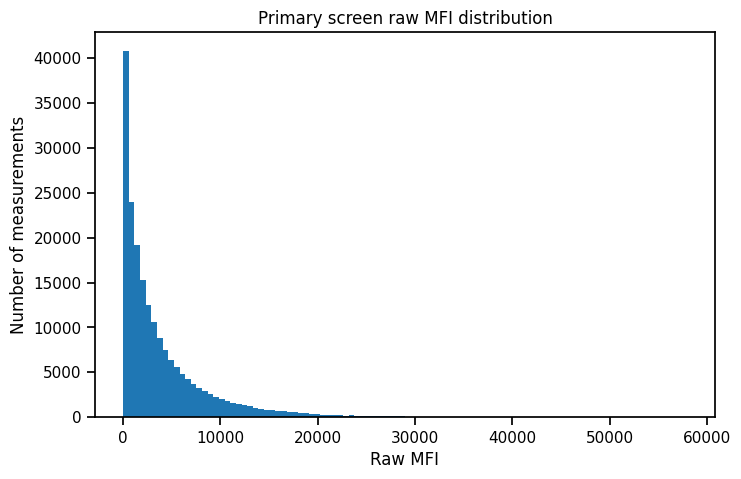

In [ ]:
# Use a random sample so the plot is fast and readable
mfi_sample = primary_mfi_values.stack().sample(
    n=200_000,
    random_state=1
)

plt.figure(figsize=(8, 5))
plt.hist(mfi_sample, bins=100)
plt.xlabel("Raw MFI")
plt.ylabel("Number of measurements")
plt.title("Primary screen raw MFI distribution")
plt.show()

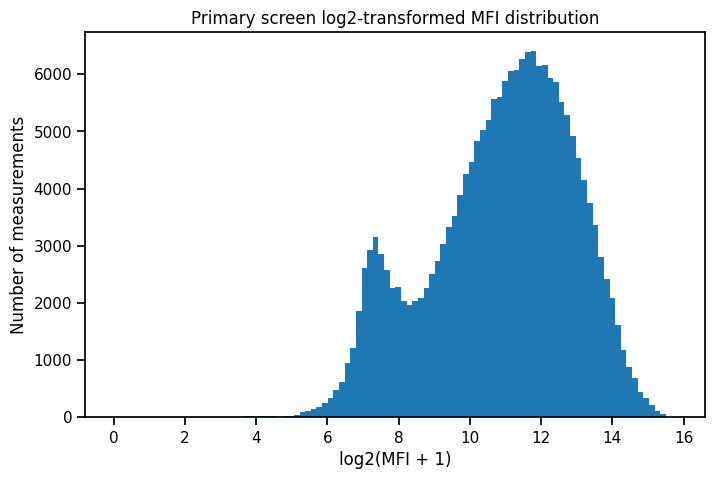

In [ ]:
# Add 1 to avoid problems if any MFI values are zero
log2_mfi_sample = np.log2(mfi_sample + 1)

plt.figure(figsize=(8, 5))
plt.hist(log2_mfi_sample, bins=100)
plt.xlabel("log2(MFI + 1)")
plt.ylabel("Number of measurements")
plt.title("Primary screen log2-transformed MFI distribution")
plt.show()

In [ ]:
non_positive_count = (primary_mfi_values <= 0).sum().sum()
non_positive_fraction = non_positive_count / primary_mfi_values.size

print("Non-positive MFI values:", non_positive_count)
print("Fraction non-positive MFI values:", non_positive_fraction)

Non-positive MFI values: 74
Fraction non-positive MFI values: 7.377789901281183e-06


### 1.3 Primary Control Behavior

Vehicle controls represent baseline viability under DMSO treatment. Positive controls are expected to reduce viability and therefore should generally produce lower MFI values.

A good screen should show separation between vehicle and positive controls. We first inspect this globally, then later at the plate and cell-line level.

In [ ]:
vehicle_cols = primary_well_metadata.loc[
    primary_well_metadata["perturbation_type"] == "vehicle_control",
    "column_name"
].tolist()

positive_cols = primary_well_metadata.loc[
    primary_well_metadata["perturbation_type"] == "positive_control",
    "column_name"
].tolist()

experimental_cols = primary_well_metadata.loc[
    primary_well_metadata["perturbation_type"] == "experimental_treatment",
    "column_name"
].tolist()

print("Vehicle control wells:", len(vehicle_cols))
print("Positive control wells:", len(positive_cols))
print("Experimental treatment wells:", len(experimental_cols))

KeyError: 'column_name'

In [ ]:
# Repair primary_well_metadata so column_name is preserved as a normal column

primary_well_metadata = (
    primary_treatment
    .set_index("column_name", drop=False)
    .loc[mfi_well_columns]
    .copy()
    .reset_index(drop=True)
)

print("primary_well_metadata shape:", primary_well_metadata.shape)
print("Columns:")
print(primary_well_metadata.columns.tolist())

print("\nDoes column_name exist?")
print("column_name" in primary_well_metadata.columns)

print("\nAlignment check:")
print(list(primary_well_metadata["column_name"]) == list(mfi_well_columns))

primary_well_metadata shape: (17058, 18)
Columns:
['column_name', 'broad_id', 'name', 'dose', 'perturbation_type', 'screen_id', 'detection_plate', 'compound_plate', 'well', 'detection_plate_scan_time', 'vendor_id', 'purity', 'moa', 'target', 'disease.area', 'indication', 'smiles', 'phase']

Does column_name exist?
True

Alignment check:
True


In [ ]:
vehicle_cols = primary_well_metadata.loc[
    primary_well_metadata["perturbation_type"] == "vehicle_control",
    "column_name"
].tolist()

positive_cols = primary_well_metadata.loc[
    primary_well_metadata["perturbation_type"] == "positive_control",
    "column_name"
].tolist()

experimental_cols = primary_well_metadata.loc[
    primary_well_metadata["perturbation_type"] == "experimental_treatment",
    "column_name"
].tolist()

print("Vehicle control wells:", len(vehicle_cols))
print("Positive control wells:", len(positive_cols))
print("Experimental treatment wells:", len(experimental_cols))

Vehicle control wells: 1518
Positive control wells: 1458
Experimental treatment wells: 14082


In [ ]:
vehicle_mfi_sample = primary_mfi_values[vehicle_cols].stack().sample(
    n=min(100_000, primary_mfi_values[vehicle_cols].stack().shape[0]),
    random_state=1
)

positive_mfi_sample = primary_mfi_values[positive_cols].stack().sample(
    n=min(100_000, primary_mfi_values[positive_cols].stack().shape[0]),
    random_state=1
)

control_mfi_summary = pd.DataFrame({
    "vehicle_control": vehicle_mfi_sample.describe(),
    "positive_control": positive_mfi_sample.describe(),
})

display(control_mfi_summary)

,vehicle_control,positive_control
count,97497.000000,97539.000000
mean,4330.305691,477.137212
std,5093.776256,1335.254137
min,15.000000,0.000000
25%,1028.000000,122.000000
50%,2562.000000,165.000000
75%,5708.000000,255.500000
max,59044.500000,50076.000000


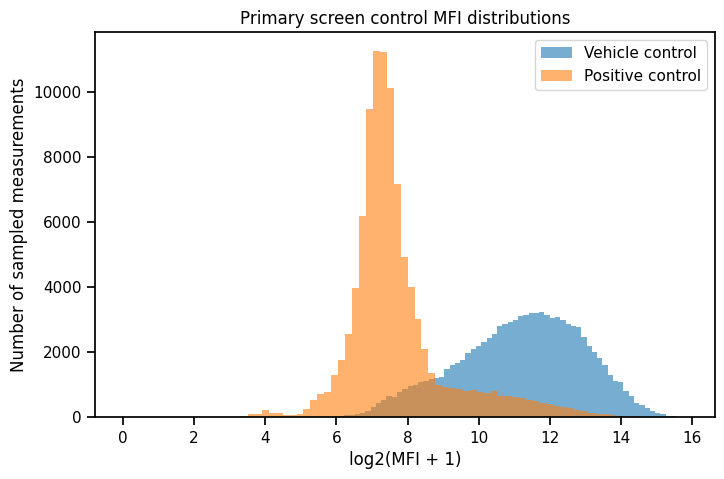

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    np.log2(vehicle_mfi_sample + 1),
    bins=80,
    alpha=0.6,
    label="Vehicle control"
)

plt.hist(
    np.log2(positive_mfi_sample + 1),
    bins=80,
    alpha=0.6,
    label="Positive control"
)

plt.xlabel("log2(MFI + 1)")
plt.ylabel("Number of sampled measurements")
plt.title("Primary screen control MFI distributions")
plt.legend()
plt.show()

In [ ]:
print("Median vehicle log2(MFI + 1):", np.log2(vehicle_mfi_sample + 1).median())
print("Median positive log2(MFI + 1):", np.log2(positive_mfi_sample + 1).median())
print("Difference, vehicle - positive:", np.log2(vehicle_mfi_sample + 1).median() - np.log2(positive_mfi_sample + 1).median())

Median vehicle log2(MFI + 1): 11.323617763291578
Median positive log2(MFI + 1): 7.3750394313469245
Difference, vehicle - positive: 3.9485783319446535


### 1.4 Plate-Level Primary Control Separation

The global control separation looked strong, but a good screen also needs consistent control behavior across detection plates.

For each detection plate, we summarize the median log2 MFI of vehicle controls and positive controls. A larger positive value for `vehicle_minus_positive` means the plate has clear assay dynamic range.

In [ ]:
primary_log2_mfi_values = np.log2(primary_mfi_values + 1)

print("Primary log2 MFI matrix shape:", primary_log2_mfi_values.shape)

Primary log2 MFI matrix shape: (588, 17058)


In [ ]:
well_log2_medians = primary_log2_mfi_values.median(axis=0, skipna=True)

primary_well_qc = primary_well_metadata.copy()
primary_well_qc["median_log2_mfi"] = primary_well_qc["column_name"].map(well_log2_medians)

display(primary_well_qc.head())

print("Missing well medians:", primary_well_qc["median_log2_mfi"].isna().sum())

,column_name,broad_id,name,dose,perturbation_type,screen_id,detection_plate,compound_plate,well,detection_plate_scan_time,vendor_id,purity,moa,target,disease.area,indication,smiles,phase,median_log2_mfi
0,PREP001_X1:A01::HTS,BRD-K60230970-001-14-2,MG-132,20.0,positive_control,HTS,PREP001_X1,PREP001,A01,2/11/2016 10:09 AM,S2619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.686501
1,PREP001_X1:A02::HTS,NaN,NaN,NaN,vehicle_control,HTS,PREP001_X1,PREP001,A02,2/11/2016 10:09 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.240040
2,PREP001_X1:A03::HTS,BRD-A96485169-001-14-3,EBPC,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A03,2/11/2016 10:09 AM,518,91.11,aldose reductase inhibitor,AKR1B1,NaN,NaN,CCOC(=O)C1CN(Cc2ccccc2)C(=O)C1=O,Preclinical,12.106972
3,PREP001_X1:A04::HTS,BRD-K35559145-050-08-5,levomepromazine,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A04,2/11/2016 10:09 AM,Prestw-797,76.90,dopamine receptor antagonist,"ADRA1A, ADRA1B, ADRA1D, ADRA2A, ADRA2B, ADRA2C...","neurology/psychiatry, gastroenterology","psychosis, schizophrenia, bipolar disorder, na...","COc1ccc2Sc3ccccc3N(C[C@H](C)CN(C)C)c2c1, COc1c...",Launched,12.117953
4,PREP001_X1:A05::HTS,BRD-A48015106-004-08-9,8-hydroxy-DPAT,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A05,2/11/2016 10:09 AM,529,93.13,serotonin receptor agonist,"CDK1, CHEK1, CHEK2, GSK3B, HTR5A, HTR7, LCK, M...",NaN,NaN,CCCN(CCC)C1CCc2cccc(O)c2C1,Preclinical,12.149582


Missing well medians: 0


In [ ]:
plate_control_qc = (
    primary_well_qc[
        primary_well_qc["perturbation_type"].isin(["vehicle_control", "positive_control"])
    ]
    .groupby(["detection_plate", "perturbation_type"])["median_log2_mfi"]
    .median()
    .unstack()
    .reset_index()
)

plate_control_qc["vehicle_minus_positive"] = (
    plate_control_qc["vehicle_control"] - plate_control_qc["positive_control"]
)

display(plate_control_qc.head(10))

print("Plate-level control separation summary:")
display(plate_control_qc["vehicle_minus_positive"].describe())

perturbation_type,detection_plate,positive_control,vehicle_control,vehicle_minus_positive
0,PMTS001_X1,8.139542,11.388533,3.248990
1,PMTS001_X2,8.390159,10.881640,2.491482
2,PMTS001_X3,7.967220,10.897608,2.930388
3,PMTS002_X1,8.125344,11.265981,3.140637
4,PMTS002_X2,7.874207,11.155975,3.281768
5,PMTS002_X3,8.318531,11.351066,3.032535
6,PMTS003_X1,8.959282,11.012106,2.052824
7,PMTS003_X2,8.330348,10.962980,2.632632
8,PMTS003_X3,8.422633,11.278934,2.856301
9,PREP001_X1,6.560319,11.938642,5.378323


Plate-level control separation summary:


count    48.000000
mean      3.964660
std       0.722172
min       2.052824
25%       3.459428
50%       4.143756
75%       4.367181
max       5.378323
Name: vehicle_minus_positive, dtype: float64

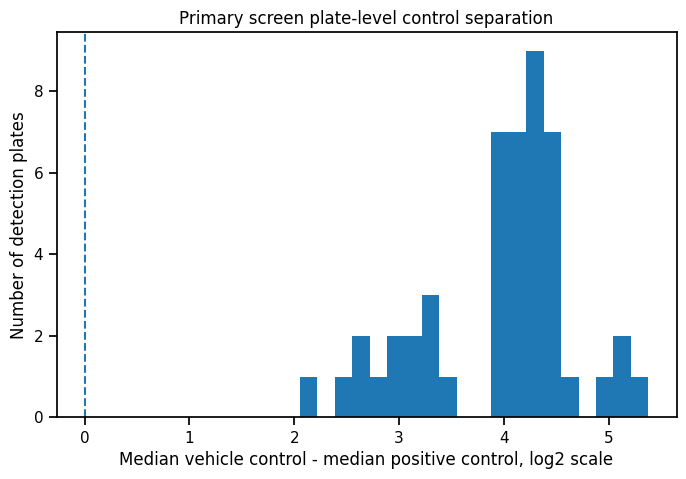

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(plate_control_qc["vehicle_minus_positive"], bins=20)
plt.axvline(0, linestyle="--")
plt.xlabel("Median vehicle control - median positive control, log2 scale")
plt.ylabel("Number of detection plates")
plt.title("Primary screen plate-level control separation")
plt.show()

In [ ]:
weak_control_plates = plate_control_qc.loc[
    plate_control_qc["vehicle_minus_positive"] <= 1
].copy()

print("Plates with vehicle-positive separation <= 1 log2 unit:")
print(weak_control_plates.shape[0])

display(weak_control_plates)

Plates with vehicle-positive separation <= 1 log2 unit:
0


perturbation_type,detection_plate,positive_control,vehicle_control,vehicle_minus_positive


**Plate-level control interpretation.** Vehicle controls show higher median log2(MFI + 1) than positive controls across all primary detection plates. This suggests that the primary screen has consistent plate-level assay dynamic range. At this stage, no detection plate is flagged for absent or failed control separation, although later QC steps may still identify well-level, cell-line-level, or batch-level issues.

### 1.5 Primary Cell-Line-Level QC

Each row in the primary MFI matrix represents a cell line barcode. Before normalization, we check whether each cell line has enough usable raw MFI measurements and whether its overall signal is unusually low.

This helps separate technical failures, such as poor barcode recovery, from true biological non-response.

In [111]:
primary_cell_line_qc = pd.DataFrame({
    "row_name": primary_cell_line_ids,
    "missing_fraction": primary_mfi_values.isna().mean(axis=1),
    "median_log2_mfi": primary_log2_mfi_values.median(axis=1, skipna=True),
    "mean_log2_mfi": primary_log2_mfi_values.mean(axis=1, skipna=True),
})

print("Primary cell-line QC shape:", primary_cell_line_qc.shape)
display(primary_cell_line_qc.head())

print("Cell-line missing fraction summary:")
display(primary_cell_line_qc["missing_fraction"].describe())

print("Cell-line median log2 MFI summary:")
display(primary_cell_line_qc["median_log2_mfi"].describe())

Primary cell-line QC shape: (588, 4)


,row_name,missing_fraction,median_log2_mfi,mean_log2_mfi
0,ACH-000001,0.002404,8.455327,8.497677
1,ACH-000007,0.000938,11.428884,10.901692
2,ACH-000008,0.000997,12.990370,12.342245
3,ACH-000010_FAILED_STR,0.000879,12.325727,11.817457
4,ACH-000011,0.000997,12.893207,12.244545


Cell-line missing fraction summary:


count    588.000000
mean       0.023795
std        0.130204
min        0.000469
25%        0.000938
50%        0.002052
75%        0.002404
max        1.000000
Name: missing_fraction, dtype: float64

Cell-line median log2 MFI summary:


count    578.000000
mean      11.327998
std        1.351126
min        7.679480
25%       10.334483
50%       11.425737
75%       12.302273
max       14.807682
Name: median_log2_mfi, dtype: float64

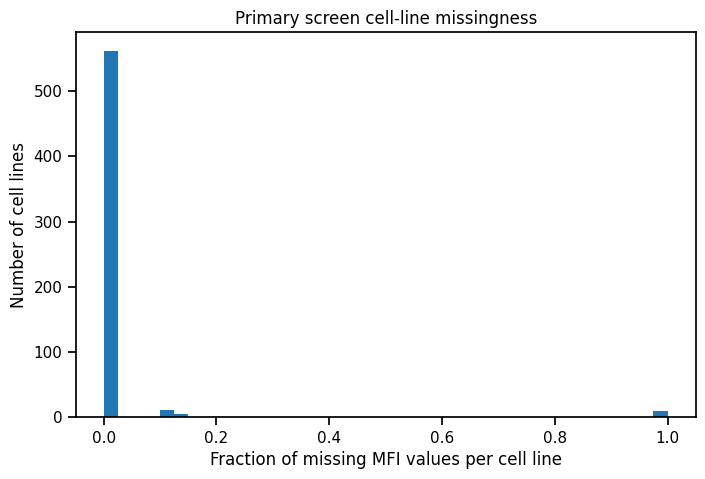

In [112]:
plt.figure(figsize=(8, 5))
plt.hist(primary_cell_line_qc["missing_fraction"], bins=40)
plt.xlabel("Fraction of missing MFI values per cell line")
plt.ylabel("Number of cell lines")
plt.title("Primary screen cell-line missingness")
plt.show()

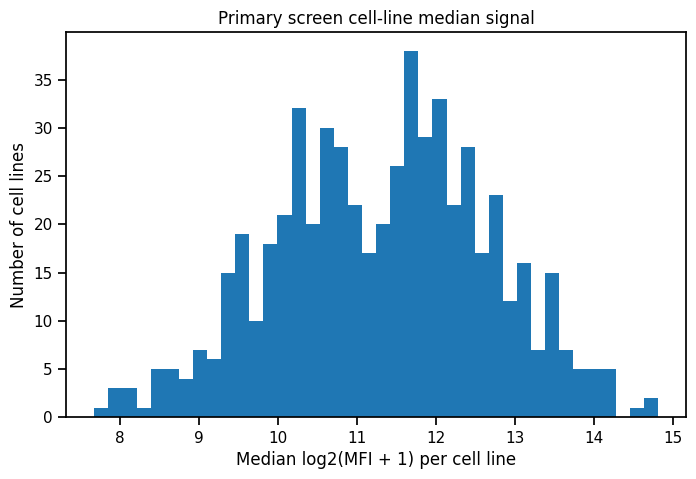

In [113]:
plt.figure(figsize=(8, 5))
plt.hist(primary_cell_line_qc["median_log2_mfi"], bins=40)
plt.xlabel("Median log2(MFI + 1) per cell line")
plt.ylabel("Number of cell lines")
plt.title("Primary screen cell-line median signal")
plt.show()

In [114]:
high_missing_cell_lines = primary_cell_line_qc.loc[
    primary_cell_line_qc["missing_fraction"] > 0.20
].copy()

low_signal_threshold = primary_cell_line_qc["median_log2_mfi"].quantile(0.01)

low_signal_cell_lines = primary_cell_line_qc.loc[
    primary_cell_line_qc["median_log2_mfi"] <= low_signal_threshold
].copy()

print("Cell lines with >20% missing values:", high_missing_cell_lines.shape[0])
print("Low-signal threshold, bottom 1% median log2 MFI:", low_signal_threshold)
print("Cell lines in bottom 1% signal:", low_signal_cell_lines.shape[0])

display(high_missing_cell_lines.head())
display(low_signal_cell_lines.head())

Cell lines with >20% missing values: 10
Low-signal threshold, bottom 1% median log2 MFI: 8.186211797647424
Cell lines in bottom 1% signal: 6


,row_name,missing_fraction,median_log2_mfi,mean_log2_mfi
578,CONTROL_BARCODE_1,1.0,NaN,NaN
579,CONTROL_BARCODE_10,1.0,NaN,NaN
580,CONTROL_BARCODE_2,1.0,NaN,NaN
581,CONTROL_BARCODE_3,1.0,NaN,NaN
582,CONTROL_BARCODE_4,1.0,NaN,NaN


,row_name,missing_fraction,median_log2_mfi,mean_log2_mfi
53,ACH-000120,0.002404,7.888743,7.892716
63,ACH-000149,0.002169,8.116344,8.132129
236,ACH-000480,0.123696,7.906891,7.825486
264,ACH-000530,0.023449,7.679480,7.714691
267,ACH-000535,0.001290,8.182394,8.129789


**Cell-line-level QC interpretation.** Most primary screen cell-line rows have very low missingness. The rows with 100% missing values are control barcode rows rather than cancer cell lines, so they should not be treated as biological non-response. A small number of real cell lines have low median signal and should be flagged for later caution rather than removed immediately.

In [115]:
primary_cell_line_qc["is_control_barcode"] = primary_cell_line_qc["row_name"].str.startswith("CONTROL_BARCODE")

print("Control barcode rows:")
display(primary_cell_line_qc["is_control_barcode"].value_counts())

display(
    primary_cell_line_qc.loc[
        primary_cell_line_qc["is_control_barcode"]
    ]
)

Control barcode rows:


is_control_barcode
False    578
True      10
Name: count, dtype: int64

,row_name,missing_fraction,median_log2_mfi,mean_log2_mfi,is_control_barcode
578,CONTROL_BARCODE_1,1.0,NaN,NaN,True
579,CONTROL_BARCODE_10,1.0,NaN,NaN,True
580,CONTROL_BARCODE_2,1.0,NaN,NaN,True
581,CONTROL_BARCODE_3,1.0,NaN,NaN,True
582,CONTROL_BARCODE_4,1.0,NaN,NaN,True
583,CONTROL_BARCODE_5,1.0,NaN,NaN,True
584,CONTROL_BARCODE_6,1.0,NaN,NaN,True
585,CONTROL_BARCODE_7,1.0,NaN,NaN,True
586,CONTROL_BARCODE_8,1.0,NaN,NaN,True
587,CONTROL_BARCODE_9,1.0,NaN,NaN,True


In [116]:
primary_real_cell_line_qc = primary_cell_line_qc.loc[
    ~primary_cell_line_qc["is_control_barcode"]
].copy()

print("Real primary cell-line rows:", primary_real_cell_line_qc.shape[0])

print("Missing fraction summary, real cell lines only:")
display(primary_real_cell_line_qc["missing_fraction"].describe())

print("Median log2 MFI summary, real cell lines only:")
display(primary_real_cell_line_qc["median_log2_mfi"].describe())

Real primary cell-line rows: 578
Missing fraction summary, real cell lines only:


count    578.000000
mean       0.006906
std        0.021095
min        0.000469
25%        0.000938
50%        0.002052
75%        0.002404
max        0.146031
Name: missing_fraction, dtype: float64

Median log2 MFI summary, real cell lines only:


count    578.000000
mean      11.327998
std        1.351126
min        7.679480
25%       10.334483
50%       11.425737
75%       12.302273
max       14.807682
Name: median_log2_mfi, dtype: float64

In [117]:
high_missing_real_cell_lines = primary_real_cell_line_qc.loc[
    primary_real_cell_line_qc["missing_fraction"] > 0.20
].copy()

low_signal_real_threshold = primary_real_cell_line_qc["median_log2_mfi"].quantile(0.01)

low_signal_real_cell_lines = primary_real_cell_line_qc.loc[
    primary_real_cell_line_qc["median_log2_mfi"] <= low_signal_real_threshold
].copy()

print("Real cell lines with >20% missing values:", high_missing_real_cell_lines.shape[0])
print("Low-signal threshold among real cell lines:", low_signal_real_threshold)
print("Real cell lines in bottom 1% signal:", low_signal_real_cell_lines.shape[0])

display(high_missing_real_cell_lines)
display(low_signal_real_cell_lines)

Real cell lines with >20% missing values: 0
Low-signal threshold among real cell lines: 8.186211797647424
Real cell lines in bottom 1% signal: 6


,row_name,missing_fraction,median_log2_mfi,mean_log2_mfi,is_control_barcode


,row_name,missing_fraction,median_log2_mfi,mean_log2_mfi,is_control_barcode
53,ACH-000120,0.002404,7.888743,7.892716,False
63,ACH-000149,0.002169,8.116344,8.132129,False
236,ACH-000480,0.123696,7.906891,7.825486,False
264,ACH-000530,0.023449,7.679480,7.714691,False
267,ACH-000535,0.001290,8.182394,8.129789,False
269,ACH-000539_FAILED_STR,0.002169,7.918863,7.906264,False


### 1.6 Primary Well-Level QC

Each column in the primary MFI matrix is a physical well measurement. We now summarize each well across real cell lines to identify wells with high missingness or unusual signal.

These are descriptive QC flags only. We will not remove wells silently.

In [119]:
# Use only real cell-line rows for well-level QC
real_cell_line_mask = ~primary_cell_line_qc["is_control_barcode"]

primary_mfi_values_real = primary_mfi_values.loc[real_cell_line_mask]
primary_log2_mfi_values_real = primary_log2_mfi_values.loc[real_cell_line_mask]

primary_well_qc["missing_fraction_real_cell_lines"] = (
    primary_mfi_values_real.isna().mean(axis=0).values
)

primary_well_qc["mean_log2_mfi_real_cell_lines"] = (
    primary_log2_mfi_values_real.mean(axis=0, skipna=True).values
)

primary_well_qc["std_log2_mfi_real_cell_lines"] = (
    primary_log2_mfi_values_real.std(axis=0, skipna=True).values
)

print("Primary well QC shape:", primary_well_qc.shape)

print("Well missing fraction summary across real cell lines:")
display(primary_well_qc["missing_fraction_real_cell_lines"].describe())

print("Well median log2 MFI summary:")
display(primary_well_qc["median_log2_mfi"].describe())

display(primary_well_qc.head())

Primary well QC shape: (17058, 22)
Well missing fraction summary across real cell lines:


count    17058.000000
mean         0.006906
std          0.025289
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.541522
Name: missing_fraction_real_cell_lines, dtype: float64

Well median log2 MFI summary:


count    17058.000000
mean        10.877633
std          1.415861
min          4.339740
25%         10.764454
50%         11.394563
75%         11.706657
max         12.946174
Name: median_log2_mfi, dtype: float64

,column_name,broad_id,name,dose,perturbation_type,screen_id,detection_plate,compound_plate,well,detection_plate_scan_time,vendor_id,purity,moa,target,disease.area,indication,smiles,phase,median_log2_mfi,missing_fraction_real_cell_lines,mean_log2_mfi_real_cell_lines,std_log2_mfi_real_cell_lines
0,PREP001_X1:A01::HTS,BRD-K60230970-001-14-2,MG-132,20.0,positive_control,HTS,PREP001_X1,PREP001,A01,2/11/2016 10:09 AM,S2619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.686501,0.0,6.798198,1.472574
1,PREP001_X1:A02::HTS,NaN,NaN,NaN,vehicle_control,HTS,PREP001_X1,PREP001,A02,2/11/2016 10:09 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.240040,0.0,11.991264,1.565231
2,PREP001_X1:A03::HTS,BRD-A96485169-001-14-3,EBPC,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A03,2/11/2016 10:09 AM,518,91.11,aldose reductase inhibitor,AKR1B1,NaN,NaN,CCOC(=O)C1CN(Cc2ccccc2)C(=O)C1=O,Preclinical,12.106972,0.0,11.946168,1.536249
3,PREP001_X1:A04::HTS,BRD-K35559145-050-08-5,levomepromazine,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A04,2/11/2016 10:09 AM,Prestw-797,76.90,dopamine receptor antagonist,"ADRA1A, ADRA1B, ADRA1D, ADRA2A, ADRA2B, ADRA2C...","neurology/psychiatry, gastroenterology","psychosis, schizophrenia, bipolar disorder, na...","COc1ccc2Sc3ccccc3N(C[C@H](C)CN(C)C)c2c1, COc1c...",Launched,12.117953,0.0,11.928547,1.570674
4,PREP001_X1:A05::HTS,BRD-A48015106-004-08-9,8-hydroxy-DPAT,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A05,2/11/2016 10:09 AM,529,93.13,serotonin receptor agonist,"CDK1, CHEK1, CHEK2, GSK3B, HTR5A, HTR7, LCK, M...",NaN,NaN,CCCN(CCC)C1CCc2cccc(O)c2C1,Preclinical,12.149582,0.0,11.984411,1.568564


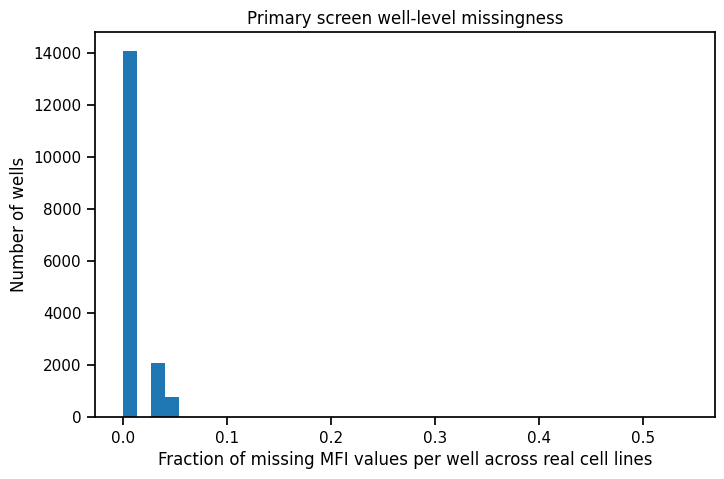

In [120]:
plt.figure(figsize=(8, 5))
plt.hist(primary_well_qc["missing_fraction_real_cell_lines"], bins=40)
plt.xlabel("Fraction of missing MFI values per well across real cell lines")
plt.ylabel("Number of wells")
plt.title("Primary screen well-level missingness")
plt.show()

In [121]:
high_missing_wells = primary_well_qc.loc[
    primary_well_qc["missing_fraction_real_cell_lines"] > 0.20
].copy()

low_signal_well_threshold = primary_well_qc["median_log2_mfi"].quantile(0.01)

low_signal_wells = primary_well_qc.loc[
    primary_well_qc["median_log2_mfi"] <= low_signal_well_threshold
].copy()

print("Wells with >20% missing values across real cell lines:", high_missing_wells.shape[0])
print("Low-signal well threshold, bottom 1% median log2 MFI:", low_signal_well_threshold)
print("Wells in bottom 1% signal:", low_signal_wells.shape[0])

display(high_missing_wells.head())
display(low_signal_wells.head())

Wells with >20% missing values across real cell lines: 68
Low-signal well threshold, bottom 1% median log2 MFI: 6.832890014164741
Wells in bottom 1% signal: 172


,column_name,broad_id,name,dose,perturbation_type,screen_id,detection_plate,compound_plate,well,detection_plate_scan_time,vendor_id,purity,moa,target,disease.area,indication,smiles,phase,median_log2_mfi,missing_fraction_real_cell_lines,mean_log2_mfi_real_cell_lines,std_log2_mfi_real_cell_lines
56,PREP001_X1:C09::HTS,BRD-K64422603-300-02-7,N-alpha-Methylhistamine-dihydrochloride,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,C09,3/18/2016 12:51 PM,573,100.00,histamine receptor agonist,HRH4,NaN,NaN,CNCCc1cnc[nH]1,Phase 3,11.390302,0.519031,11.205868,1.824299
371,PREP001_X1:P12::HTS,BRD-K61397605-001-03-4,romidepsin,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,P12,3/18/2016 12:51 PM,HY-15149,98.84,HDAC inhibitor,"HDAC1, HDAC2, HDAC3, HDAC4, HDAC5, HDAC6, HDAC...",hematologic malignancy,cutaneous T-cell lymphoma (CTCL),C\C=C1/NC(=O)[C@H]2CSSCC\C=C\[C@H](CC(=O)N[C@H...,Launched,6.584963,0.519031,6.704562,0.656503
1688,PREP002_X2:G09::HTS,BRD-K47598052-001-15-8,PP-1,2.5,experimental_treatment,HTS,PREP002_X2,PREP002,G09,3/8/2016 10:47 AM,1397,99.39,src inhibitor,"HCK, RET",NaN,NaN,"Cc1ccc(cc1)-c1nn(c2ncnc(N)c12)C(C)(C)C, Cc1ccc...",Preclinical,10.756545,0.207612,10.679573,1.824342
1707,PREP002_X2:H04::HTS,BRD-A18233884-003-02-7,bevantolol,2.5,experimental_treatment,HTS,PREP002_X2,PREP002,H04,3/8/2016 10:47 AM,69996,94.05,adrenergic receptor antagonist,"ADRA1A, ADRB1, ADRB2",cardiology,"angina pectoris, hypertension",COc1ccc(CCNCC(O)COc2cccc(C)c2)cc1OC,Launched,11.384244,0.278547,11.240257,1.603364
1744,PREP002_X2:I17::HTS,BRD-K47827687-001-02-2,amprenavir,2.5,experimental_treatment,HTS,PREP002_X2,PREP002,I17,3/8/2016 10:47 AM,S1639,95.63,HIV protease inhibitor,NaN,infectious disease,human immunodeficiency virus (HIV-1),CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,Launched,11.030658,0.411765,10.950990,1.709560


,column_name,broad_id,name,dose,perturbation_type,screen_id,detection_plate,compound_plate,well,detection_plate_scan_time,vendor_id,purity,moa,target,disease.area,indication,smiles,phase,median_log2_mfi,missing_fraction_real_cell_lines,mean_log2_mfi_real_cell_lines,std_log2_mfi_real_cell_lines
0,PREP001_X1:A01::HTS,BRD-K60230970-001-14-2,MG-132,20.0,positive_control,HTS,PREP001_X1,PREP001,A01,2/11/2016 10:09 AM,S2619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.686501,0.0,6.798198,1.472574
22,PREP001_X1:A23::HTS,BRD-K88510285-001-22-8,bortezomib,20.0,positive_control,HTS,PREP001_X1,PREP001,A23,2/11/2016 10:09 AM,S1013,NaN,"NFkB pathway inhibitor, proteasome inhibitor","PSMA1, PSMA2, PSMA3, PSMA4, PSMA5, PSMA6, PSMA...",hematologic malignancy,"multiple myeloma, mantle cell lymphoma (MCL)",CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)c1cncc...,Launched,6.442943,0.0,7.108742,1.897334
24,PREP001_X1:B01::HTS,BRD-K60230970-001-14-2,MG-132,20.0,positive_control,HTS,PREP001_X1,PREP001,B01,2/11/2016 10:09 AM,S2619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.781360,0.0,7.351259,1.420101
46,PREP001_X1:B23::HTS,BRD-K88510285-001-22-8,bortezomib,20.0,positive_control,HTS,PREP001_X1,PREP001,B23,2/11/2016 10:09 AM,S1013,NaN,"NFkB pathway inhibitor, proteasome inhibitor","PSMA1, PSMA2, PSMA3, PSMA4, PSMA5, PSMA6, PSMA...",hematologic malignancy,"multiple myeloma, mantle cell lymphoma (MCL)",CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)c1cncc...,Launched,6.566049,0.0,7.481949,1.998411
70,PREP001_X1:C23::HTS,BRD-K88510285-001-22-8,bortezomib,20.0,positive_control,HTS,PREP001_X1,PREP001,C23,2/11/2016 10:09 AM,S1013,NaN,"NFkB pathway inhibitor, proteasome inhibitor","PSMA1, PSMA2, PSMA3, PSMA4, PSMA5, PSMA6, PSMA...",hematologic malignancy,"multiple myeloma, mantle cell lymphoma (MCL)",CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)c1cncc...,Launched,6.266787,0.0,6.868970,1.759053


**Well-level QC interpretation.** Most wells have low missingness across real cell lines, but 68 wells have more than 20% missing MFI values. Low median signal is not automatically a technical failure because positive controls are expected to reduce barcode abundance. The next check asks whether high-missing wells cluster by plate or perturbation type.

In [122]:
print("High-missing wells by perturbation type:")
display(
    high_missing_wells["perturbation_type"]
    .value_counts(dropna=False)
)

print("All wells by perturbation type:")
display(
    primary_well_qc["perturbation_type"]
    .value_counts(dropna=False)
)

High-missing wells by perturbation type:


perturbation_type
experimental_treatment    57
positive_control           6
vehicle_control            5
Name: count, dtype: int64

All wells by perturbation type:


perturbation_type
experimental_treatment    14082
vehicle_control            1518
positive_control           1458
Name: count, dtype: int64

In [123]:
high_missing_by_plate = (
    high_missing_wells
    .groupby("detection_plate")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="high_missing_well_count")
)

display(high_missing_by_plate.head(20))

print("Number of plates with at least one high-missing well:")
print(high_missing_by_plate.shape[0])

,detection_plate,high_missing_well_count
0,PREP004_X1,7
1,PREP008_X3,7
2,PREP006_X2,6
3,PREP011_X2,5
4,PREP005_X3,3
5,PREP003_X3,3
6,PREP002_X2,3
7,PREP012_X1,3
8,PREP011_X1,3
9,PMTS002_X2,3


Number of plates with at least one high-missing well:
28


In [124]:
plate_well_counts = (
    primary_well_qc
    .groupby("detection_plate")
    .size()
    .reset_index(name="total_wells")
)

plate_missing_qc = (
    plate_well_counts
    .merge(high_missing_by_plate, on="detection_plate", how="left")
)

plate_missing_qc["high_missing_well_count"] = (
    plate_missing_qc["high_missing_well_count"].fillna(0).astype(int)
)

plate_missing_qc["high_missing_well_fraction"] = (
    plate_missing_qc["high_missing_well_count"] / plate_missing_qc["total_wells"]
)

plate_missing_qc = plate_missing_qc.sort_values(
    "high_missing_well_fraction",
    ascending=False
)

display(plate_missing_qc.head(20))

,detection_plate,total_wells,high_missing_well_count,high_missing_well_fraction
32,PREP008_X3,384,7,0.018229
18,PREP004_X1,384,7,0.018229
25,PREP006_X2,384,6,0.015625
40,PREP011_X2,379,5,0.013193
4,PMTS002_X2,283,3,0.010601
39,PREP011_X1,379,3,0.007916
23,PREP005_X3,384,3,0.007812
13,PREP002_X2,384,3,0.007812
17,PREP003_X3,384,3,0.007812
22,PREP005_X2,384,3,0.007812


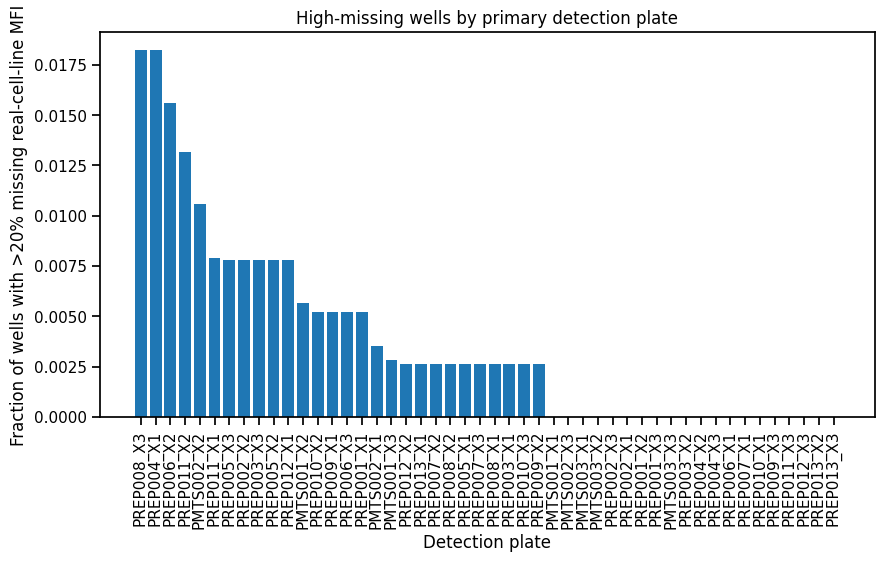

In [125]:
plt.figure(figsize=(10, 5))
plt.bar(
    plate_missing_qc["detection_plate"],
    plate_missing_qc["high_missing_well_fraction"]
)
plt.xticks(rotation=90)
plt.xlabel("Detection plate")
plt.ylabel("Fraction of wells with >20% missing real-cell-line MFI")
plt.title("High-missing wells by primary detection plate")
plt.show()

### 1.7 Primary QC Decision Table

QC flags should be explicit and reproducible. Here we combine the primary QC results into simple flags for wells and cell lines.

At this stage, we are not permanently deleting data. We are marking technical concerns so that later normalization and hit calling can either exclude or stratify affected measurements in a transparent way.

In [126]:
primary_well_qc["flag_high_missing"] = (
    primary_well_qc["missing_fraction_real_cell_lines"] > 0.20
)

primary_well_qc["flag_low_signal"] = (
    primary_well_qc["median_log2_mfi"] <= low_signal_well_threshold
)

primary_well_qc["qc_flag"] = "pass"

primary_well_qc.loc[
    primary_well_qc["flag_high_missing"],
    "qc_flag"
] = "high_missing"

primary_well_qc.loc[
    primary_well_qc["flag_low_signal"] & ~primary_well_qc["flag_high_missing"],
    "qc_flag"
] = "low_signal"

print("Primary well QC flag counts:")
display(primary_well_qc["qc_flag"].value_counts())

Primary well QC flag counts:


qc_flag
pass            16819
low_signal        171
high_missing       68
Name: count, dtype: int64

In [127]:
well_qc_by_type = (
    primary_well_qc
    .groupby(["perturbation_type", "qc_flag"])
    .size()
    .unstack(fill_value=0)
)

display(well_qc_by_type)

qc_flag,high_missing,low_signal,pass
perturbation_type,,,
experimental_treatment,57,16,14009
positive_control,6,155,1297
vehicle_control,5,0,1513


In [128]:
primary_real_cell_line_qc["flag_high_missing"] = (
    primary_real_cell_line_qc["missing_fraction"] > 0.20
)

primary_real_cell_line_qc["flag_low_signal"] = (
    primary_real_cell_line_qc["median_log2_mfi"] <= low_signal_real_threshold
)

primary_real_cell_line_qc["qc_flag"] = "pass"

primary_real_cell_line_qc.loc[
    primary_real_cell_line_qc["flag_high_missing"],
    "qc_flag"
] = "high_missing"

primary_real_cell_line_qc.loc[
    primary_real_cell_line_qc["flag_low_signal"] & ~primary_real_cell_line_qc["flag_high_missing"],
    "qc_flag"
] = "low_signal"

print("Primary real cell-line QC flag counts:")
display(primary_real_cell_line_qc["qc_flag"].value_counts())

display(primary_real_cell_line_qc.loc[
    primary_real_cell_line_qc["qc_flag"] != "pass"
])

Primary real cell-line QC flag counts:


qc_flag
pass          572
low_signal      6
Name: count, dtype: int64

,row_name,missing_fraction,median_log2_mfi,mean_log2_mfi,is_control_barcode,flag_high_missing,flag_low_signal,qc_flag
53,ACH-000120,0.002404,7.888743,7.892716,False,False,True,low_signal
63,ACH-000149,0.002169,8.116344,8.132129,False,False,True,low_signal
236,ACH-000480,0.123696,7.906891,7.825486,False,False,True,low_signal
264,ACH-000530,0.023449,7.679480,7.714691,False,False,True,low_signal
267,ACH-000535,0.001290,8.182394,8.129789,False,False,True,low_signal
269,ACH-000539_FAILED_STR,0.002169,7.918863,7.906264,False,False,True,low_signal


In [129]:
primary_well_qc.to_csv(
    TABLES_DIR / "primary_well_qc.csv",
    index=False
)

primary_real_cell_line_qc.to_csv(
    TABLES_DIR / "primary_real_cell_line_qc.csv",
    index=False
)

plate_control_qc.to_csv(
    TABLES_DIR / "primary_plate_control_qc.csv",
    index=False
)

print("Saved primary QC tables:")
print(TABLES_DIR / "primary_well_qc.csv")
print(TABLES_DIR / "primary_real_cell_line_qc.csv")
print(TABLES_DIR / "primary_plate_control_qc.csv")

Saved primary QC tables:
C:\Users\shash\Desktop\Code for assignment\results\tables\primary_well_qc.csv
C:\Users\shash\Desktop\Code for assignment\results\tables\primary_real_cell_line_qc.csv
C:\Users\shash\Desktop\Code for assignment\results\tables\primary_plate_control_qc.csv


### Section 1 Multiple-Choice Question

**Question.** Based on the primary screen QC, which statement best describes the main technical interpretation before normalization?

A) The primary screen should be discarded because many detection plates lack vehicle or positive controls.  
B) The primary screen has usable plate-level dynamic range, but a small number of wells and low-signal cell lines should be flagged before normalization.  
C) Low-signal wells should all be removed because low MFI always indicates technical failure.  
D) The fully missing control barcode rows indicate that many cancer cell lines failed barcode detection.

**Best answer: B**

**Rationale.** Vehicle and positive controls are present on all detection plates and show clear separation, supporting usable assay dynamic range. Some wells have high missingness and a small number of real cell lines have low signal, so these should be tracked as QC flags. Low MFI is not automatically failure because positive controls are expected to lower barcode abundance. Fully missing control barcode rows are not cancer cell lines.